# Basic Blog Writing

In [56]:
from __future__ import annotations

import operator
from typing import TypedDict,List,Annotated
from pathlib import Path
from dotenv import load_dotenv

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send

from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_core.output_parsers import PydanticOutputParser


In [57]:
load_dotenv()

True

In [58]:
class Task(BaseModel):
    id:int
    title:str
    brief:str=Field(description="what to cover")

In [59]:
class Plan(BaseModel):
    blog_title:str
    tasks:list[Task]

In [60]:
class State(TypedDict):
    topic:str
    plan:Plan
    sections:Annotated[List[str],operator.add]
    result:str


In [61]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [62]:
parser = PydanticOutputParser(pydantic_object=Plan)

structured_model = model | parser

In [63]:
def orchestrator(state:State)-> dict:
    format_instructions=parser.get_format_instructions()
    plan=structured_model.invoke([
        SystemMessage(
            content=f"Generate a plan on this blog with 5-7 section on the following topic.\n\n{format_instructions}"
        ),
        HumanMessage(
            content=f"Topic: {state['topic']}"
        )
    ])
    return{
        "plan":plan
    }

In [64]:
def no_of_worker(state:State):
    return [
        Send("Worker",{"task":task,"topic":state["topic"],"plan":state["plan"]})
        for task in state["plan"].tasks
    ]

In [65]:
def worker(payload:dict)->dict:

    task=payload['task']
    topic=payload['topic']
    plan=payload['plan']

    blog_title=plan.blog_title

    section_md=model.invoke([
        SystemMessage(
            content="Write one clean Markdown Section"
        ),
        HumanMessage(
            content=(
                f'Blog:{blog_title}\n'
                f'Topic:{topic}\n\n'
                f'section:{task.title}\n\n'
                f'Brief:{task.brief}\n\n'
                "Return only the section content in Markdown."
            )
        )
    ]).content.strip()

    return{
        'sections':[section_md]
    }



In [66]:
def reducer(state:State)->dict:
    title=state['plan'].blog_title
    body="\n\n".join(state['sections']).strip()

    result=f'#{title}\n\n{body}\n'

    filename=title.lower().replace(" ","-")+".md"
    output_path=Path(filename)
    output_path.write_text(result,encoding="utf-8")

    return{
        "result":result
    }

In [67]:
graph=StateGraph(State)

graph.add_node("Orchestrator",orchestrator)
graph.add_node("Worker",worker)
graph.add_node("Reducer",reducer)

In [68]:
graph.add_edge(START,"Orchestrator")
graph.add_conditional_edges("Orchestrator",no_of_worker,["Worker"])
graph.add_edge("Worker","Reducer")
graph.add_edge("Reducer",END)

app=graph.compile()

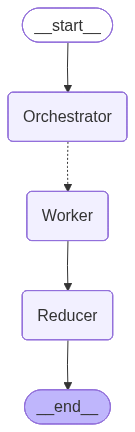

In [69]:
app

In [70]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [71]:
print(out['plan'])

blog_title='Understanding Self-Attention: A Deep Dive' tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain the core idea behind self-attention, why it was introduced, and the problems it solves compared to traditional sequence models.'), Task(id=2, title='Mechanics of Self-Attention', brief='Detail the query‑key‑value mechanism, showing how dot products compute attention scores and how the weighted sum produces the output.'), Task(id=3, title='Scaled Dot-Product Attention', brief='Describe the scaling factor (√d_k), the role of the softmax function, and why scaling stabilizes gradients for large dimensionalities.'), Task(id=4, title='Multi-Head Attention', brief='Explain how multiple attention heads capture diverse relationships, the concatenation process, and the linear projections that follow.'), Task(id=5, title='Self-Attention in Transformer Architectures', brief='Show how self-attention integrates into encoder and decoder stacks, the importance of positional e